# 作业A：显微 TIFF 图像读取与分析

## 任务目标

1. 使用 tifffile 读取显微 TIFF 图像
2. 输出图像的 shape、dtype、min、max 和 mean
3. 并排展示原始图像与灰度直方图
4. 保存分析结果图

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

In [3]:
tiff_path = Path(
    r"D:\re-c6 10ms exp 2s inteval 100mw-1.tif"
)

print("文件路径：")
print(tiff_path)

print("\n文件是否存在：")
print(tiff_path.exists())

if tiff_path.exists():
    file_size_mb = (
        tiff_path.stat().st_size
        / 1024**2
    )

    print(
        "\n文件大小：",
        round(file_size_mb, 2),
        "MB"
    )

文件路径：
D:\re-c6 10ms exp 2s inteval 100mw-1.tif

文件是否存在：
True

文件大小： 240.01 MB


In [4]:
with tifffile.TiffFile(tiff_path) as tif:
    series = tif.series[0]

    print("TIFF页数：", len(tif.pages))
    print("完整序列形状：", series.shape)
    print("完整序列类型：", series.dtype)

    image = tif.pages[0].asarray()

TIFF页数： 60
完整序列形状： (60, 1024, 1024)
完整序列类型： float32


In [5]:
print("\n当前分析对象：第0帧")
print("第一帧形状：", image.shape)
print("第一帧类型：", image.dtype)
print("第一帧最小值：", image.min())
print("第一帧最大值：", image.max())
print(
    "第一帧平均值：",
    round(float(image.mean()), 4)
)


当前分析对象：第0帧
第一帧形状： (1024, 1024)
第一帧类型： float32
第一帧最小值： 0.0
第一帧最大值： 1053.3096
第一帧平均值： 85.9272


显示下限： 0.0
显示上限： 590.2064590454102


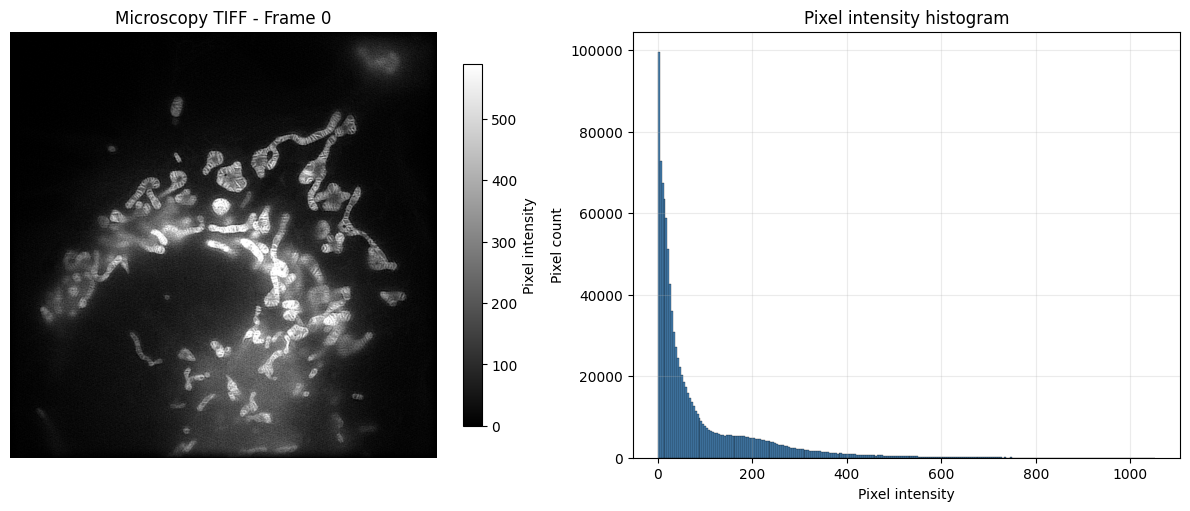

In [6]:
# 计算适合显示的灰度范围
display_min, display_max = np.percentile(
    image,
    [1, 99.5]
)

print("显示下限：", display_min)
print("显示上限：", display_max)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True
)

# 左图：第0帧显微图像
image_plot = axes[0].imshow(
    image,
    cmap="gray",
    vmin=display_min,
    vmax=display_max
)

axes[0].set_title("Microscopy TIFF - Frame 0")
axes[0].axis("off")

fig.colorbar(
    image_plot,
    ax=axes[0],
    label="Pixel intensity",
    shrink=0.85
)

# 右图：第0帧像素强度直方图
axes[1].hist(
    image.ravel(),
    bins=256,
    color="steelblue",
    edgecolor="black",
    linewidth=0.2
)

axes[1].set_title("Pixel intensity histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Pixel count")
axes[1].grid(alpha=0.25)

plt.show()

In [7]:
# 创建作业结果文件夹
output_dir = Path(
    r"C:\Users\ET\projects\dl-learning-journey"
) / "assignments" / "02_tiff_analysis" / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# 设置输出图片路径
output_path = (
    output_dir
    / "tiff_frame0_and_histogram.png"
)

# 保存刚才的整张图
fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

print("结果图已保存：")
print(output_path)

print("\n文件是否存在：")
print(output_path.exists())

print("\n文件大小：")
print(
    round(
        output_path.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

结果图已保存：
C:\Users\ET\projects\dl-learning-journey\assignments\02_tiff_analysis\outputs\tiff_frame0_and_histogram.png

文件是否存在：
True

文件大小：
0.64 MB
